Tutorial


```
https://youtu.be/mTVf7BN7S8w?si=Iojwqvt0o3tLU5a9
```





In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
import PIL
import os

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [2]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url,cache_dir='.',untar=True)

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [3]:
data_dir

'./datasets/flower_photos'

In [4]:
import pathlib

data_dir = pathlib.Path(data_dir)
data_dir

PosixPath('datasets/flower_photos')

In [5]:
data_dir = data_dir / 'flower_photos'
data_dir

PosixPath('datasets/flower_photos/flower_photos')

In [6]:
image_count = len(list(data_dir.glob('*/*.jpg')))
image_count

3670

In [7]:
roses = list(data_dir.glob('roses/*'))
len(roses)

641

In [8]:
roses[:5]

[PosixPath('datasets/flower_photos/flower_photos/roses/18760363474_a707331322_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/9633056561_6f1b7e8faf_m.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/2788276815_8f730bd942.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/6255593451_b8a3aa8f7a_m.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/16209331331_343c899d38.jpg')]

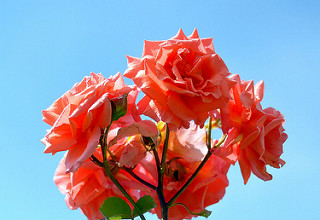

In [9]:
PIL.Image.open(str(roses[0]))

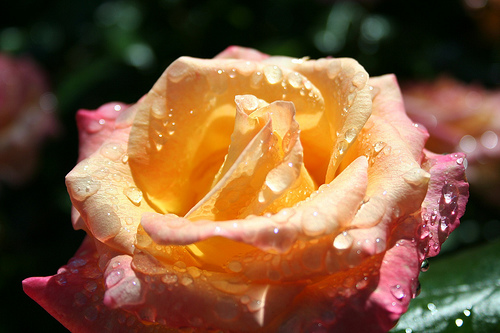

In [10]:
PIL.Image.open(str(roses[15]))

In [11]:
tulips = list(data_dir.glob('tulips/*'))

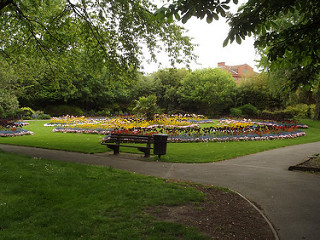

In [12]:
PIL.Image.open(str(tulips[0]))

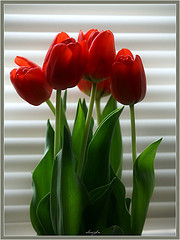

In [13]:
PIL.Image.open(str(tulips[15]))

In [14]:
flowers_image__dict = {
    'roses': list(data_dir.glob('roses/*')),
    'daisy': list(data_dir.glob('daisy/*')),
    'dandelion': list(data_dir.glob('dandelion/*')),
    'sunflowers': list(data_dir.glob('sunflowers/*')),
    'tulips': list(data_dir.glob('tulips/*')),
}

In [15]:
flowers_image__dict['roses']

[PosixPath('datasets/flower_photos/flower_photos/roses/18760363474_a707331322_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/9633056561_6f1b7e8faf_m.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/2788276815_8f730bd942.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/6255593451_b8a3aa8f7a_m.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/16209331331_343c899d38.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/3072908271_08764c732a_m.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/4702438868_278b9cf41c_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/12202373204_34fb07205b.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/4242976586_607a8f9843_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/2960709681_e95940c0f0_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/2423565102_2f1a00bb1b_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/31

In [16]:
flowers_label_dict = {
    'roses': 0,
    'daisy': 1,
    'dandelion': 2,
    'sunflowers': 3,
    'tulips': 4,
}

In [17]:
flowers_image__dict['roses'][len(roses) - 1]

PosixPath('datasets/flower_photos/flower_photos/roses/5249566718_6109630c83_m.jpg')

In [18]:
img = cv2.imread(str(flowers_image__dict['roses'][0]))

array([[[253, 204, 126],
        [253, 204, 126],
        [253, 204, 126],
        ...,
        [243, 184, 114],
        [242, 183, 113],
        [242, 183, 113]],

       [[253, 204, 126],
        [253, 204, 126],
        [253, 204, 126],
        ...,
        [243, 184, 114],
        [242, 183, 113],
        [242, 183, 113]],

       [[253, 204, 126],
        [253, 204, 126],
        [252, 203, 125],
        ...,
        [243, 184, 114],
        [243, 184, 114],
        [243, 184, 114]],

       ...,

       [[253, 231, 153],
        [253, 231, 153],
        [253, 231, 153],
        ...,
        [251, 217, 147],
        [251, 217, 147],
        [251, 217, 147]],

       [[253, 231, 153],
        [253, 231, 153],
        [253, 231, 153],
        ...,
        [251, 217, 147],
        [251, 217, 147],
        [251, 217, 147]],

       [[253, 231, 153],
        [253, 231, 153],
        [253, 231, 153],
        ...,
        [250, 217, 144],
        [252, 216, 146],
        [252, 216, 146]]], dtype=uint8)
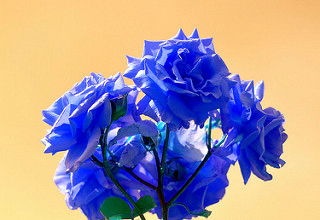

In [19]:
img

In [20]:
img.shape

(220, 320, 3)

In [21]:
a = cv2.resize(img,(180,180))

In [22]:
a.shape

(180, 180, 3)

In [23]:
X, Y = [], []

for flower_name, images in flowers_image__dict.items():
  for image in images:
    img = cv2.imread(str(image))
    resize_img = cv2.resize(img,(180,180))
    X.append(resize_img)
    Y.append(flowers_label_dict[flower_name])

In [24]:
len(X)

3670

In [25]:
len(Y)

3670

In [26]:
Y[:5]

[0, 0, 0, 0, 0]

array([[[ 25, 107,  85],
        [ 24, 119, 106],
        [ 23,  96,  87],
        ...,
        [ 41, 140, 130],
        [ 44, 139, 130],
        [ 44, 142, 127]],

       [[ 35, 153, 151],
        [ 33, 141, 148],
        [ 25,  96,  89],
        ...,
        [ 43, 146, 140],
        [ 47, 147, 140],
        [ 46, 145, 139]],

       [[ 38, 164, 165],
        [ 32, 143, 143],
        [ 22,  92,  83],
        ...,
        [ 48, 152, 144],
        [ 47, 151, 142],
        [ 48, 151, 143]],

       ...,

       [[ 22,  42,  19],
        [ 40,  70,  36],
        [ 51,  90,  51],
        ...,
        [ 17,  19,   8],
        [ 21,  20,   8],
        [ 22,  20,   9]],

       [[ 29,  53,  25],
        [ 48,  82,  42],
        [ 55,  99,  54],
        ...,
        [ 22,  22,  10],
        [ 27,  25,  11],
        [ 26,  25,  12]],

       [[ 38,  65,  34],
        [ 57,  96,  53],
        [ 64, 114,  66],
        ...,
        [ 24,  24,  10],
        [ 28,  27,  12],
        [ 28,  28,  11]]], dtype=uint8)
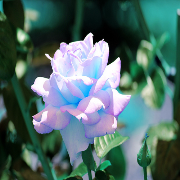

In [27]:
X[600]

In [28]:
Y[600]

0

In [29]:
x = np.array(X)
y = np.array(Y)

In [30]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.2 ,random_state=0)

In [31]:
len(x_train)

2936

In [32]:
len(x_test)

734

In [33]:
x_train = x_train/255
x_test = x_test/255

In [34]:
model = Sequential([
    layers.Conv2D(16,3,padding='same',activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32,3,padding='same',activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64,3,padding='same',activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),

    layers.Dense(128,activation='relu'),
    layers.Dense(5,activation='softmax')
])


model.compile(optimizer='adam',
              loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [35]:
model.fit(x_train,y_train,epochs=10)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/nn.py:1214: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 49ms/step - accuracy: 0.3798 - loss: 1.3931
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.6213 - loss: 0.9636
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.7033 - loss: 0.7784
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.7902 - loss: 0.5603
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8665 - loss: 0.3882
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9373 - loss: 0.2082
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9676 - loss: 0.1079
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9802 - loss: 0.0664
Epoch 9/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9768 - loss: 0.0894
Epoch 10/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9901 - loss: 0.0352


In [36]:
model.evaluate(x_test,y_test)

/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/nn.py:1214: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.6090 - loss: 2.1362


[2.136167526245117, 0.608991801738739]

In [37]:
predictions = model.predict(x_test)

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step


In [39]:
np.argmax(predictions[0])

np.int64(1)

In [40]:
y_test[0]

np.int64(1)

In [59]:
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal',input_shape=(180,180,3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


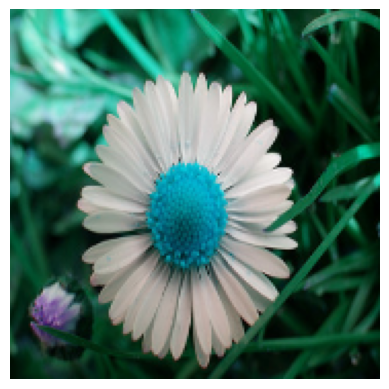

In [43]:
plt.axis('off')
plt.imshow(x_train[0])

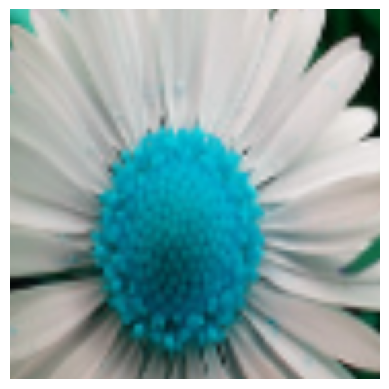

In [57]:
plt.axis('off')
plt.imshow((data_augmentation(x_train[0]).numpy() * 255).astype('uint8'))

In [61]:
model_1 = Sequential([
    data_augmentation,
    layers.Conv2D(16,3,padding='same',activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32,3,padding='same',activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64,3,padding='same',activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),
    layers.Flatten(),

    layers.Dense(128,activation='relu'),
    layers.Dense(5,activation='softmax')
])


model_1.compile(optimizer='adam',
              loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [63]:
model_1.fit(x_train,y_train,epochs=20)

Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.7755 - loss: 0.6022
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.7834 - loss: 0.5790
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.7933 - loss: 0.5438
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.8076 - loss: 0.5285
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.7970 - loss: 0.5185
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.8195 - loss: 0.4813
Epoch 7/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.8232 - loss: 0.4648
Epoch 8/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.8277 - loss: 0.4509
Epoch 9/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.8382 - loss: 0.4376
Epoch 10/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.8464 - loss: 0.4160
Epoch 11/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.8454 - loss: 0.4104
Epoch 12/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy:

In [64]:
model_1.evaluate(x_test,y_test)

/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/nn.py:1214: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7302 - loss: 1.0757


[1.075743556022644, 0.7302452325820923]